In [1]:
from pathlib import Path

import astropy.units as u
import numpy as np
import pandas as pd

from tardis.io.atom_data import AtomData
from tardis.io.configuration.config_reader import Configuration

home = Path.home()

ION_SLICE = (1, slice(None), slice(None), slice(None))

# identical atomic data to that used by C Vogl
atom_data = AtomData.from_hdf(home / "tardis-regression-data/atom_data/nlte_atom_data/TestNLTE_He_Ti_ctardis.h5") # currently not available for public use

config = Configuration.from_yaml(home / "tardis/tardis/plasma/tests/data/plasma_base_test_config.yml")
config.plasma.continuum_interaction.species = ["H 1"]

/home/afullard/tardis/tardis/__init__.py:17: UserWarning: Astropy is already imported externally. Astropy should be imported after TARDIS.
  warnings.warn(


### Set up electrons and radiation field

In [2]:
from tardis.plasma.electron_energy_distribution import (
         ThermalElectronEnergyDistribution,
)
from tardis.plasma.radiation_field import (
    DilutePlanckianRadiationField,
)

radiation_temp = 10000 * np.ones(1) * u.K
dilution_factor = 0.3 * np.ones(1)

electron_temp = 9992 * np.ones(1)
electron_density = 2.20676447e09 * np.ones(1)

elemental_number_density = pd.DataFrame(2.20676447e09 * np.ones(1), index=[1])
elemental_number_density.index.name = "atomic_number"

thermal_electron_distribution = ThermalElectronEnergyDistribution(0 * u.erg, electron_temp * u.K, electron_density * u.cm**-3)
radiation_field = DilutePlanckianRadiationField(radiation_temp, dilution_factor)

### Set up plasma

In [3]:
from tardis.plasma.assembly.base import PlasmaSolverFactory

plasma_solver_factory = PlasmaSolverFactory(atom_data, config)
plasma_solver_factory.prepare_factory([1],"tardis.plasma.properties.property_collections" )
plasma = plasma_solver_factory.assemble(elemental_number_density, radiation_field, 13 * u.day, thermal_electron_distribution.number_density, link_t_rad_t_electron=1)

### Set up ionization rate solvers

In [4]:
from tardis.plasma.equilibrium.rate_matrix import IonRateMatrix
from tardis.plasma.equilibrium.rates import (
         AnalyticPhotoionizationRateSolver,
         CollisionalIonizationRateSolver,
         EstimatedPhotoionizationRateSolver,
)

analytic_photoionization_rate_solver = AnalyticPhotoionizationRateSolver(atom_data.photoionization_data)
estimated_photoionization_rate_solver = EstimatedPhotoionizationRateSolver(atom_data.photoionization_data, atom_data.level2continuum_edge_idx)

collisional_ionization_rate_solver = CollisionalIonizationRateSolver(atom_data.photoionization_data)

ion_rate_matrix_solver = IonRateMatrix(analytic_photoionization_rate_solver, collisional_ionization_rate_solver)

### Required LTE properties

In [5]:
from tardis.plasma.properties.hydrogen_continuum import (
         LTEIonNumberDensity,
         LTELevelNumberDensity,
)

def calculate_lte_properties(plasma, electron_densities):
    lte_ion_number_density = LTEIonNumberDensity(plasma,
                                                electron_densities=electron_densities
                                                ).calculate(
                                                    plasma.thermal_phi_lte,
                                                    plasma.thermal_lte_partition_function,
                                                    plasma.number_density,
                                                    plasma.electron_densities,
                                                    None)[0]

    lte_level_number_density = LTELevelNumberDensity(plasma
                                                    ).calculate(
                                                        plasma.thermal_lte_level_boltzmann_factor,
                                                        lte_ion_number_density,
                                                        plasma.levels,
                                                        plasma.thermal_lte_partition_function)
    return lte_ion_number_density, lte_level_number_density

In [6]:
from tardis.plasma.equilibrium.ion_populations import IonPopulationSolver

solver = IonPopulationSolver(ion_rate_matrix_solver)

lte_ion_number_density, lte_level_number_density = calculate_lte_properties(plasma, thermal_electron_distribution.number_density.value)

ion_number_density, electron_number_density = solver.solve(
    radiation_field,
    thermal_electron_distribution,
    plasma.number_density,
    lte_level_number_density,
    plasma.level_number_density,
    lte_ion_number_density,
    plasma.ion_number_density,
    plasma.partition_function,
    plasma.general_level_boltzmann_factor,)

### Set up bound-bound rate solvers

In [7]:
from tardis.plasma.equilibrium.rates import (
    RadiativeRatesSolver,
    ThermalCollisionalRateSolver,
)

radiative_rate_solver = RadiativeRatesSolver(atom_data.lines.loc[ION_SLICE, :])

collisional_bound_rate_solver = ThermalCollisionalRateSolver(
    atom_data.levels,
    atom_data.lines.loc[ION_SLICE, :],
    atom_data.collision_data_temperatures,
    atom_data.yg_data.loc[atom_data.lines.loc[ION_SLICE, :].index], # handles the issue that there is more collision than line data
    "cmfgen",
    "regemorter")

rate_solvers = [(radiative_rate_solver, "radiative"), (collisional_bound_rate_solver, "electron")]

In [8]:
from tardis.plasma.equilibrium.level_populations import LevelPopulationSolver
from tardis.plasma.equilibrium.rate_matrix import RateMatrix

rate_matrix_solver = RateMatrix(rate_solvers, atom_data.levels.loc[ION_SLICE, :])

rate_matrix = rate_matrix_solver.solve(radiation_field, thermal_electron_distribution)

In [9]:
level_pop_solver = LevelPopulationSolver(rate_matrix, atom_data.levels.loc[ION_SLICE, :])

level_number_density = level_pop_solver.solve() * ion_number_density

### Set up thermal balance solver

In [10]:
from tardis.plasma.equilibrium.rates.heating_cooling_rates import (
         BoundFreeThermalRates,
         CollisionalBoundThermalRates,
         CollisionalIonizationThermalRates,
         FreeFreeThermalRates,
)

bf_rates = BoundFreeThermalRates(atom_data.photoionization_data)
ff_rates = FreeFreeThermalRates()
coll_ion_rates = CollisionalIonizationThermalRates(atom_data.photoionization_data)
coll_bound_rates = CollisionalBoundThermalRates(atom_data.lines.loc[ION_SLICE, :])

In [11]:
data_path = home / "tardis-regression-data/testdata/thermal_data"
bf_heating_estimator = pd.read_csv(data_path / "thermal_bf_heating_est.csv", index_col=(0, 1, 2))
stim_recomb_cooling_estimator = pd.read_csv(data_path / "thermal_stim_cooling_est.csv", index_col=(0, 1, 2))
level_population_ratio = pd.read_csv(data_path / "thermal_level_pop_ratio.csv", index_col=(0, 1, 2))
coll_exc_coeff = pd.read_csv(data_path / "thermal_coll_exc_coeff.csv", index_col=(0, 1, 2, 3))
coll_deexc_coeff = pd.read_csv(data_path / "thermal_coll_deexc_coeff.csv", index_col=(0, 1, 2, 3))
coll_ion_rate_coeff = pd.read_csv(data_path / "thermal_coll_ion_rate_coeff.csv", index_col=(0, 1, 2))

ff_heating_estimator = [  4.89135279e-24,   4.37696370e-24,   3.75869301e-24,
         4.97847160e-24,   4.52158002e-24,   4.21024499e-24,
         3.94991540e-24,   3.72915649e-24,   3.58902110e-24,
         3.40170224e-24,   3.20848519e-24,   3.03540032e-24,
         2.87314722e-24,   2.74328938e-24,   2.61063140e-24,
         2.50640248e-24,   2.38164559e-24,   2.26967531e-24,
         2.24509826e-24,   2.12378192e-24,   2.02063266e-24,
         1.92509873e-24,   1.83070678e-24,   1.77346374e-24]

# because pandas reads in the columns as strings, we need to convert them back to integers
bf_heating_estimator.columns = bf_heating_estimator.columns.astype(int)
stim_recomb_cooling_estimator.columns = stim_recomb_cooling_estimator.columns.astype(int)
level_population_ratio.columns = level_population_ratio.columns.astype(int)
coll_exc_coeff.columns = coll_exc_coeff.columns.astype(int)
coll_deexc_coeff.columns = coll_deexc_coeff.columns.astype(int)
coll_ion_rate_coeff.columns = coll_ion_rate_coeff.columns.astype(int)

In [12]:
from tardis.plasma.equilibrium.rates.collisional_ionization_strengths import (
         CollisionalIonizationSeaton,
)
from tardis.plasma.equilibrium.thermal_balance import ThermalBalanceSolver

collisional_ionization_rate_coeff = CollisionalIonizationSeaton(atom_data.photoionization_data).solve(thermal_electron_distribution.temperature)
collisional_bound_rate_coeff = collisional_bound_rate_solver.solve(thermal_electron_distribution.temperature)

thermal_solver = ThermalBalanceSolver(bf_rates, ff_rates, coll_ion_rates, coll_bound_rates)

heating_rate, fractional_heating_rate = thermal_solver.solve(
    thermal_electron_distribution,
    level_number_density.loc[:, [0]],
    ion_number_density.loc[:, [0]],
    collisional_ionization_rate_coeff.loc[:, [0]],
    collisional_bound_rate_coeff.iloc[419:, [0]],
    collisional_bound_rate_coeff.iloc[:419, [0]],
    ff_heating_estimator[0],
    level_population_ratio.loc[:, [0]],
    bound_free_heating_estimator=bf_heating_estimator.loc[:, [0]],
    stimulated_recombination_estimator=stim_recomb_cooling_estimator.loc[:, [0]],
)

<Axes: xlabel='atomic_number,ion_number,level_number'>

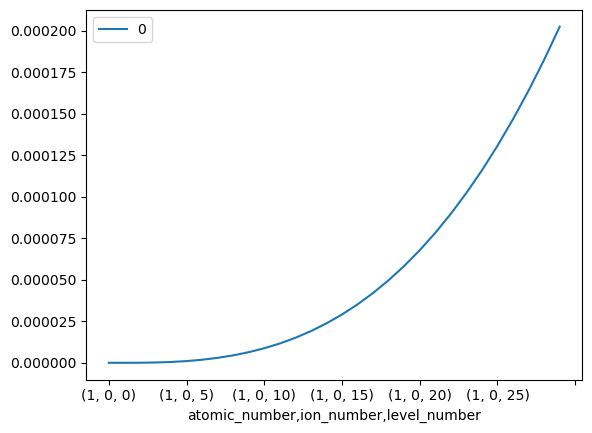

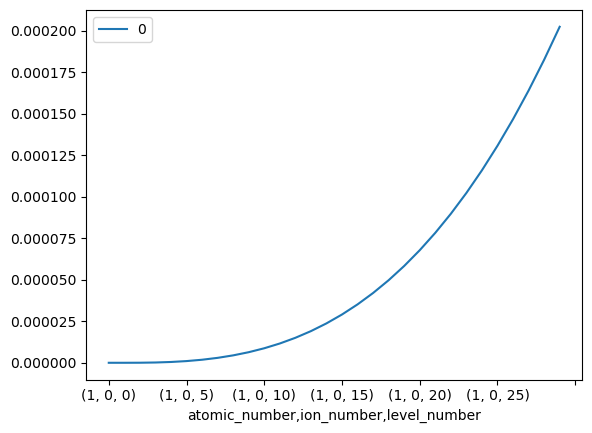

In [13]:
coll_ion_rate_coeff.loc[:, [0]].plot()
collisional_ionization_rate_coeff.plot()

<Axes: xlabel='atomic_number,ion_number,level_number_source,level_number_destination'>

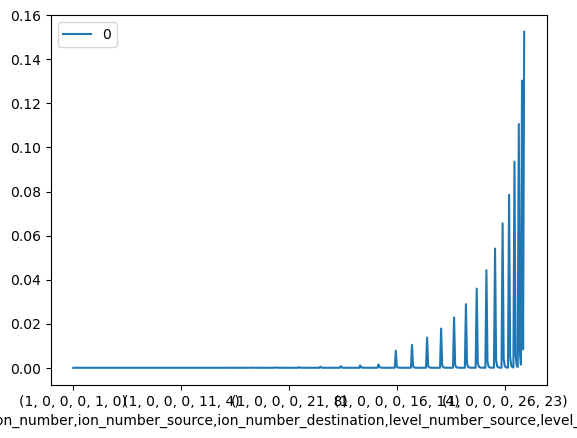

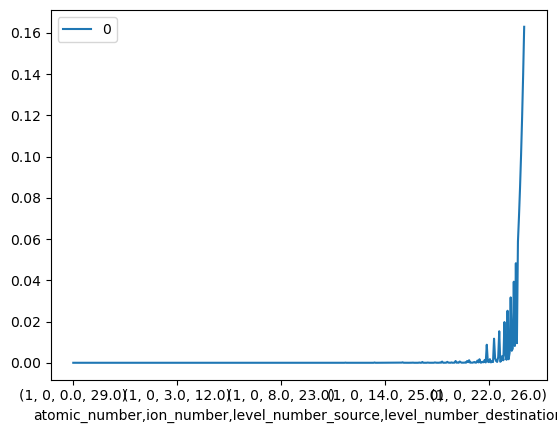

In [14]:
collisional_bound_rate_coeff.iloc[419:, [0]].plot()
coll_exc_coeff.loc[:, [0]].plot()

<Axes: xlabel='atomic_number,ion_number,level_number_destination,level_number_source'>

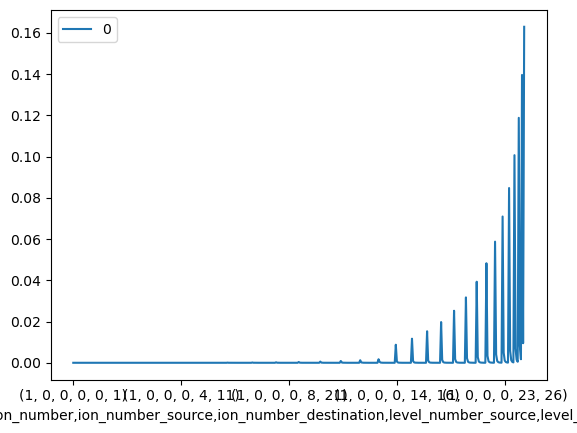

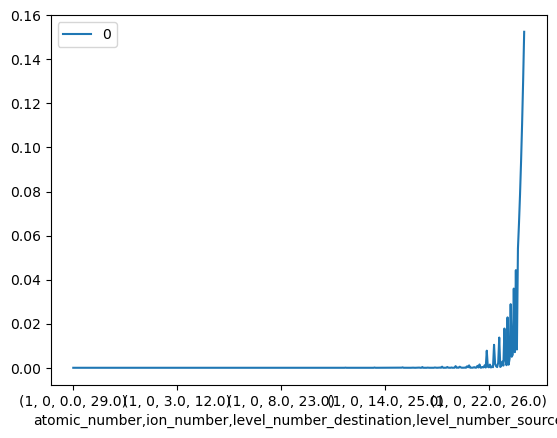

In [15]:
collisional_bound_rate_coeff.iloc[:419, [0]].plot()
coll_deexc_coeff.loc[:, [0]].plot()

In [16]:
coll_deexc_coeff.loc[:, [0]].shape

(435, 1)

In [17]:
thermal_electron_distribution.number_density = electron_number_density.to_numpy() * u.cm**-3

# initial link guess
plasma.update(
    link_t_rad_t_electron = radiation_field.dilution_factor ** 0.25, 
    previous_level_number_density=level_number_density, 
    previous_ion_number_density=ion_number_density)

max_electron_density = (plasma.number_density * plasma.number_density.index.values).sum()

fractional_electron_density = thermal_electron_distribution.number_density / max_electron_density

print("Initial fractional electron density:\n", fractional_electron_density.values)

Initial fractional electron density:
 [0.9999927]


In [18]:
lower_ion_level_index = (
            lte_level_number_density.index.get_level_values("ion_number")
            == 0
        )

upper_ion_population_index = (
            lte_ion_number_density.index.get_level_values("ion_number")
            > 0
        )

def calculate_electron_density_fractional_heating(
        inputs,
        plasma,
        radiation_field,
        solver,
        rate_matrix_solver,
        thermal_solver,
    ):
    fractional_electron_density= inputs[::2]
    link_t_rad_t_electron = inputs[1::2]

    plasma.update(link_t_rad_t_electron=link_t_rad_t_electron, previous_electron_densities = fractional_electron_density * max_electron_density.values)

    thermal_electron_distribution = ThermalElectronEnergyDistribution(
        0 * u.erg,
        plasma.t_electrons * u.K,
        plasma.previous_electron_densities * u.cm**-3,
    )
    print(inputs)
    print(thermal_electron_distribution.temperature)
    print(thermal_electron_distribution.number_density)
    lte_ion_number_density, lte_level_number_density = calculate_lte_properties(plasma, thermal_electron_distribution.number_density.value)

    ion_number_density, electron_number_density = solver.solve(
        radiation_field,
        thermal_electron_distribution,
        plasma.number_density,
        lte_level_number_density,
        plasma.previous_level_number_density,
        lte_ion_number_density,
        plasma.previous_ion_number_density,
        plasma.partition_function,
        plasma.general_level_boltzmann_factor,
        tolerance=1e-8,)

    fractional_electron_density_change = (electron_number_density - thermal_electron_distribution.number_density.value) / thermal_electron_distribution.number_density.value

    thermal_electron_distribution.number_density = electron_number_density.to_numpy() * u.cm**-3

    rate_matrix = rate_matrix_solver.solve(radiation_field, thermal_electron_distribution)
    level_pop_solver = LevelPopulationSolver(rate_matrix, atom_data.levels.loc[ION_SLICE, :])
    level_number_density = level_pop_solver.solve() * ion_number_density

    collisional_ionization_rate_coeff = CollisionalIonizationSeaton(atom_data.photoionization_data).solve(thermal_electron_distribution.temperature)
    collisional_bound_rate_coeff = collisional_bound_rate_solver.solve(thermal_electron_distribution.temperature)

    level_to_ion_population_factor = pd.DataFrame(
        lte_level_number_density.loc[lower_ion_level_index].values / (
            lte_ion_number_density.loc[upper_ion_population_index].values
            * thermal_electron_distribution.number_density.value
        ),
        index = lte_level_number_density.loc[lower_ion_level_index].index)


    heating_rate, fractional_heating_rate = thermal_solver.solve(
        thermal_electron_distribution,
        level_number_density.loc[:, [0]],
        ion_number_density.loc[:, [0]],
        collisional_ionization_rate_coeff.loc[:, [0]],
        collisional_bound_rate_coeff.iloc[419:, [0]],
        collisional_bound_rate_coeff.iloc[:419, [0]],
        ff_heating_estimator[0],
        level_to_ion_population_factor.loc[:, [0]],
        radiation_field,
    )

    plasma.update(previous_level_number_density=level_number_density, previous_ion_number_density=ion_number_density)

    print("Fractional change in e- density:\n", fractional_electron_density_change.values)
    print("Fractional heating rate:\n", fractional_heating_rate.values)
    output = np.zeros(2 * len(radiation_field.dilution_factor))
    output[::2] = fractional_electron_density_change.values
    output[1::2] = fractional_heating_rate.values
    return output

In [ ]:
from scipy.optimize import least_squares
from scipy.sparse import block_diag

initial = np.zeros(2 * len(radiation_field.dilution_factor))
initial[::2] = fractional_electron_density.values
initial[1::2] = radiation_field.dilution_factor ** 0.25

jac_sparsity = block_diag([np.ones((2, 2))] * 1)

least_squares(calculate_electron_density_fractional_heating, 
              initial,
              bounds=([0.0, 0.15], [1.0, 1.0]),
              args=(plasma, radiation_field, solver, rate_matrix_solver, thermal_solver),
              xtol=1e-14, 
              ftol=1e-12,
              gtol=1e-14,
              x_scale='jac',
              jac_sparsity=jac_sparsity,
              verbose=2,
              max_nfev=100)

[0.9999927 0.7400828]
[7400.82804492] K
[2.20674836e+09] 1 / cm3
Fractional change in e- density:
 [-4.8513802e-05]
Fractional heating rate:
 [-0.09834708]
[0.9999927  0.74008282]
[7400.82819393] K
[2.20674836e+09] 1 / cm3
Fractional change in e- density:
 [-4.27340315e-06]
Fractional heating rate:
 [-0.09834868]
[0.99999272 0.7400828 ]
[7400.82804492] K
[2.2067484e+09] 1 / cm3
Fractional change in e- density:
 [-1.42644847e-05]
Fractional heating rate:
 [-0.09834774]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.8361e-03                                    6.15e+00    
[0.99999942 0.7400767 ]
[7400.7670368] K
[2.20676318e+09] 1 / cm3
Fractional change in e- density:
 [-1.3749223e-05]
Fractional heating rate:
 [-0.09834818]
[0.99999392 0.74008104]
[7400.81041053] K
[2.20675106e+09] 1 / cm3
Fractional change in e- density:
 [-1.17392342e-05]
Fractional heating rate:
 [-0.09834794]
[0.99999263 0.74008231]
[7400

     message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [-4.851e-05 -9.835e-02]
           x: [ 1.000e+00  7.401e-01]
        cost: 0.00483607492115114
         jac: <Compressed Sparse Row sparse matrix of dtype 'float64'
              	with 4 stored elements and shape (2, 2)>
                Coords	Values
                (0, 0)	2298.432778836156
                (0, 1)	2968.9229091520538
                (1, 0)	-44.67635284271091
                (1, 1)	-107.43173943273723
        grad: [ 4.282e+00  1.042e+01]
  optimality: 6.149585580250467
 active_mask: [0 0]
        nfev: 17
        njev: 1